# River level
<!-- markdownlint-disable MD013 -->
Koriziena (Korizéna, Gorom-Gorom, Oudalan, Sahel) river level from DGRE (seems to be only one with reasonably complete data)

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [39]:
from io import BytesIO

import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.constants import *
from src.utils.rp_calc import calculate_one_group_rp

In [ ]:
# load from blob
blob_name = f"{PROJECT_PREFIX}/raw/dgre/Donnees/KORIZIENA_Sahel.xls"
data = stratus.load_blob_data(blob_name)
xls = pd.ExcelFile(BytesIO(data))

In [6]:
# load locally
filepath = "temp/KORIZIENA_Sahel.xls"
xls = pd.ExcelFile(filepath)

In [7]:
# Initialize empty list for storing data
dfs = []

# Loop over all sheets (each named by year)
for sheet_name in xls.sheet_names:
    try:
        year = int(sheet_name)
    except ValueError:
        continue  # Skip sheets not named by year

    # Read the sheet, skip metadata rows, keep only daily values
    df = pd.read_excel(
        xls,
        sheet_name=sheet_name,
        skiprows=7,
        nrows=31,
        usecols="B:M",
        header=None,
    )

    df_long = df.melt(ignore_index=False, var_name="month", value_name="value")
    df_long = df_long.reset_index(names="day")
    df_long["day"] += 1
    df_long["year"] = year

    dfs.append(df_long)

    if year == 2023:
        display(df_long.iloc[:60])
        break

,day,month,value,year
0,1,1,NaN,2023
1,2,1,NaN,2023
2,3,1,NaN,2023
3,4,1,NaN,2023
4,5,1,NaN,2023
5,6,1,NaN,2023
6,7,1,NaN,2023
7,8,1,NaN,2023
8,9,1,NaN,2023
9,10,1,NaN,2023


In [8]:
df_all = pd.concat(dfs, ignore_index=True)

In [9]:
df_all["date"] = pd.to_datetime(
    df_all[["year", "month", "day"]], errors="coerce"
)

# Optionally drop rows with invalid dates (e.g., Feb 30)
df_all = df_all.dropna(subset=["date"])[["date", "value"]]

In [10]:
df_all = df_all.sort_values("date")

<Axes: xlabel='date'>

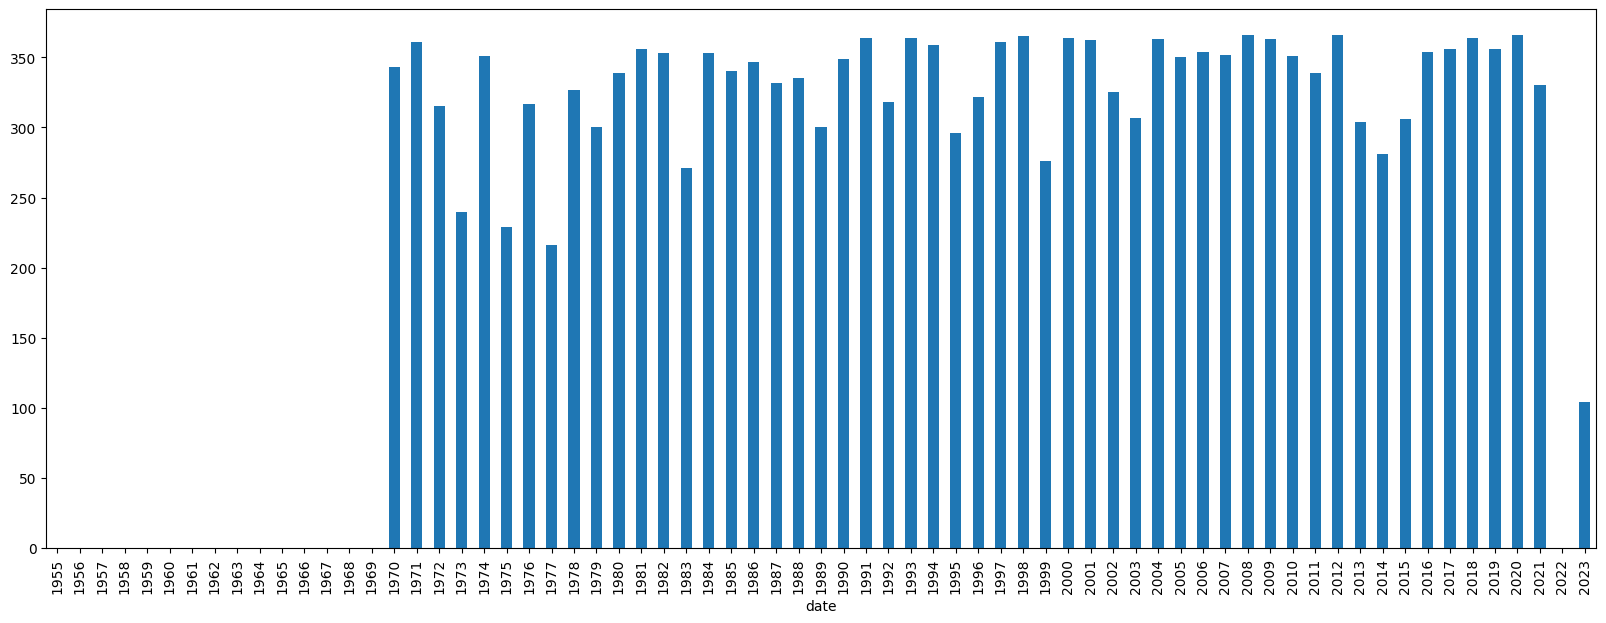

In [11]:
df_all.groupby(df_all["date"].dt.year).count()["value"].plot(
    kind="bar", figsize=(20, 7)
)

<Axes: xlabel='date'>

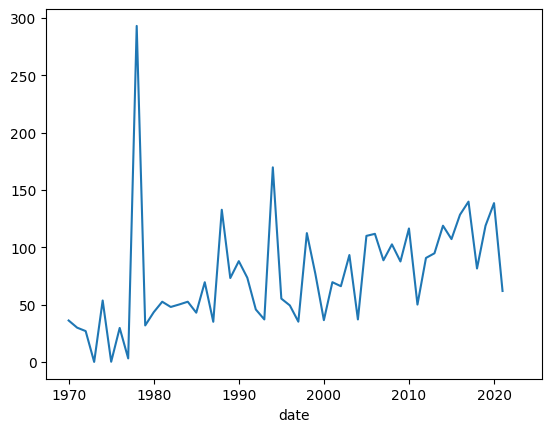

In [15]:
df_all.groupby(df_all["date"].dt.year)["value"].max().plot()

In [16]:
min_year, max_year = 1980, 2021

In [17]:
df_complete = df_all[
    df_all["date"].dt.year.isin(range(min_year, max_year + 1))
]

In [18]:
df_complete

,date,value
9300,1980-01-01,0.0
9301,1980-01-02,0.0
9302,1980-01-03,0.0
9303,1980-01-04,0.0
9304,1980-01-05,0.0
...,...,...
24919,2021-12-27,NaN
24920,2021-12-28,NaN
24921,2021-12-29,NaN
24922,2021-12-30,NaN


In [19]:
df_yearly = df_complete.loc[
    df_complete.groupby(df_complete["date"].dt.year)["value"].idxmax()
]

In [20]:
df_yearly["year"] = df_yearly["date"].dt.year

In [21]:
df_yearly

,date,value,year
9507,1980-07-22,43.349,1980
9885,1981-07-28,52.500,1981
10262,1982-08-02,47.930,1982
10628,1983-07-27,50.110,1983
11067,1984-10-01,52.500,1984
11380,1985-08-04,42.943,1985
11745,1986-07-28,69.505,1986
12085,1987-06-27,35.018,1987
12499,1988-08-07,132.713,1988
12883,1989-08-19,73.168,1989


In [22]:
df_yearly = calculate_one_group_rp(
    df_yearly, col_name="value", ascending=False
)

In [23]:
df_yearly.sort_values("value_rank")

,date,value,year,value_rank,value_rp
14729,1994-08-05,169.700,1994,1.0,43.000000
23273,2017-07-24,139.800,2017,2.0,21.500000
24413,2020-08-17,138.500,2020,3.0,14.333333
12499,1988-08-07,132.713,1988,4.0,10.750000
22895,2016-07-18,128.400,2016,5.0,8.600000
22177,2014-08-13,118.800,2014,6.5,6.615385
24032,2019-08-08,118.800,2019,6.5,6.615385
20668,2010-07-23,116.400,2010,8.0,5.375000
16253,1998-09-10,112.334,1998,9.0,4.777778
19199,2006-08-11,111.707,2006,10.0,4.300000


In [53]:
df_yearly = df_yearly.sort_values("value_rank", ascending=False)

rps = {}
for rp in [2, 3, 5, 10]:
    thresh = np.interp(rp, df_yearly["value_rp"], df_yearly["value"])
    rps.update({rp: thresh})

In [61]:
def get_rv(rp):
    df_interp = df_yearly.sort_values("value_rank", ascending=False)
    return np.interp(rp, df_interp["value_rp"], df_interp["value"])

In [62]:
get_rv(10)

131.20846511627906

In [54]:
rps

{2: 75.0702558139535,
 3: 94.22627906976744,
 5: 113.84693023255815,
 10: 131.20846511627906}

In [85]:
rp_colors = [
    (2, "gold"),
    (3, "darkorange"),
    (4, "crimson"),
    (5, "rebeccapurple"),
]

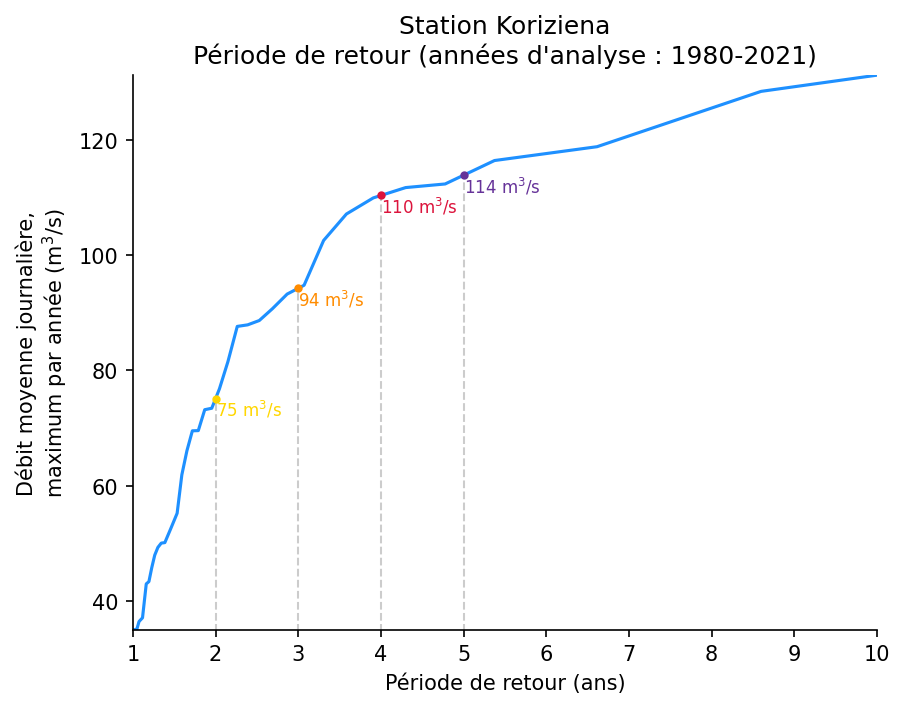

In [136]:
fig, ax = plt.subplots(dpi=150)

df_yearly.sort_values("value_rank").plot(
    x="value_rp", y="value", ax=ax, legend=False, color="dodgerblue"
)

for rp, color in rp_colors:
    rv = get_rv(rp)
    ax.plot(
        [rp, rp], [0, rv], linewidth=1, linestyle="--", color="k", alpha=0.2
    )
    ax.annotate(
        f"{rv:.0f} m$^3$/s",
        (rp, rv),
        color=color,
        fontsize=8,
        ha="left",
        va="top",
    )
    ax.plot([rp], [rv], marker=".", color=color)

top_rp = 10
ax.set_xlim((1, top_rp))
ax.set_ylim((df_yearly["value"].min(), get_rv(top_rp)))

ax.set_ylabel("Débit moyenne journalière,\nmaximum par année (m$^3$/s)")
ax.set_xlabel("Période de retour (ans)")
ax.set_title(
    "Station Koriziena\nPériode de retour (années d'analyse : 1980-2021)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [92]:
rp_colors

[(2, 'gold'), (3, 'darkorange'), (4, 'crimson'), (5, 'rebeccapurple')]

In [111]:
def add_rp_color(rp_q):
    color_out = "grey"
    for rp, color in rp_colors:
        if rp_q >= rp:
            color_out = color
        else:
            return color_out
    return color_out

In [115]:
add_rp_color(4.9)

'crimson'

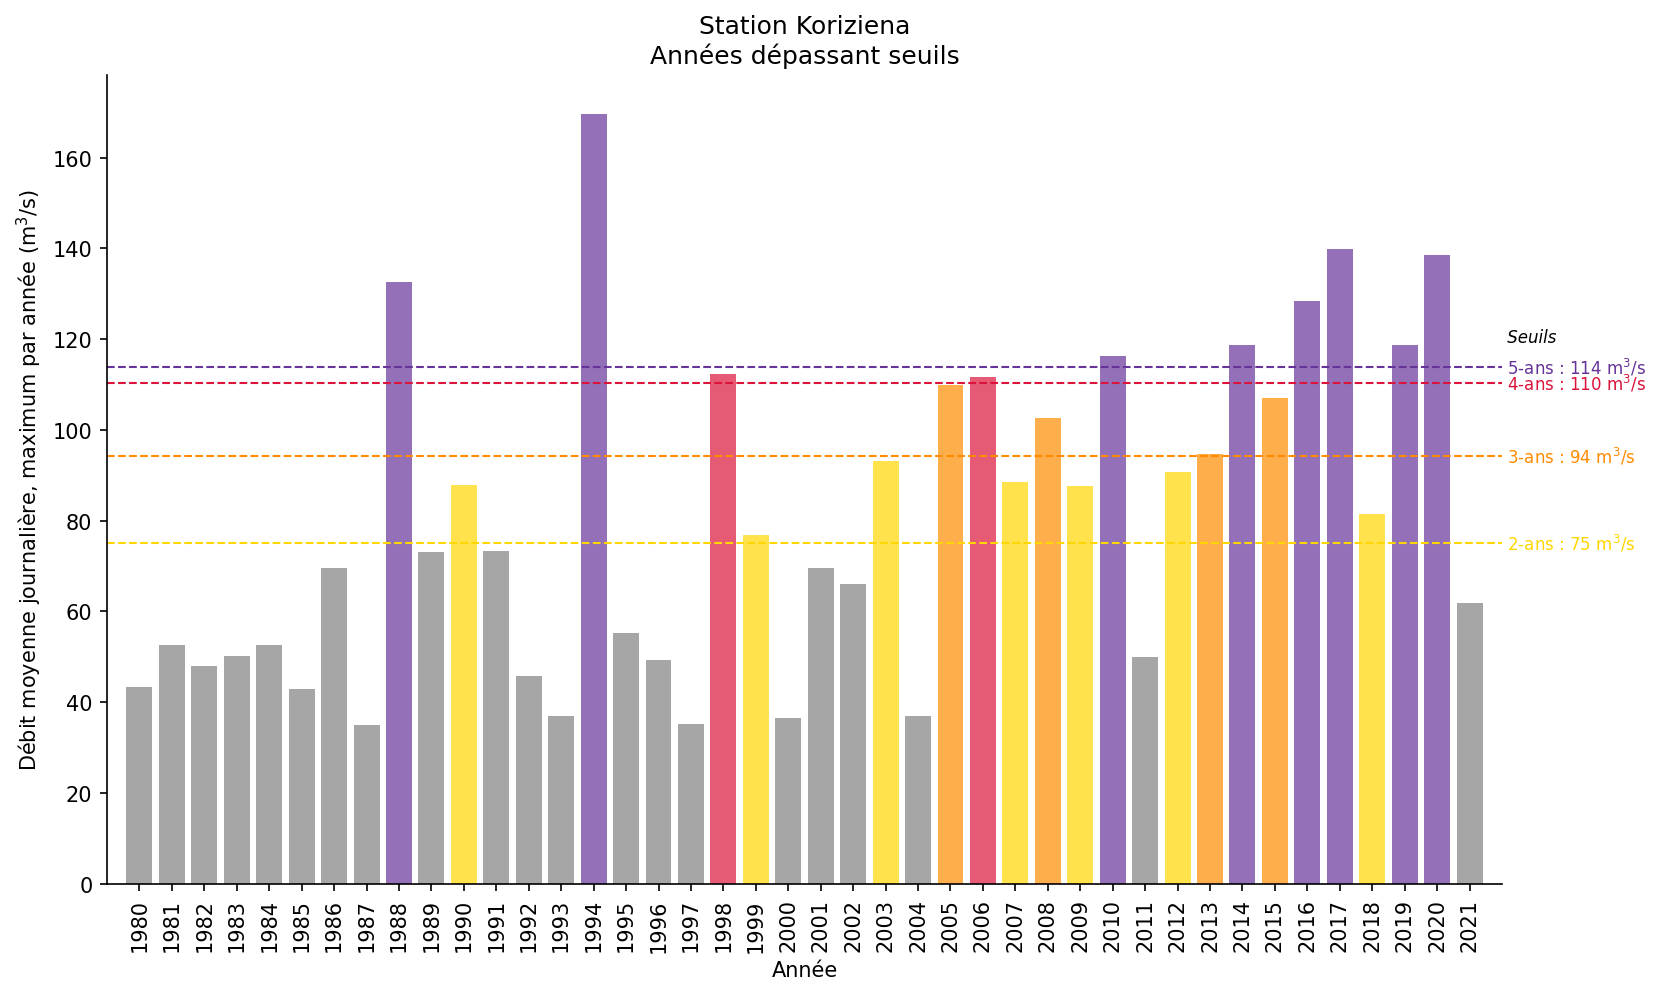

In [169]:
fig, ax = plt.subplots(dpi=150, figsize=(12, 7))

df_plot = df_yearly.sort_values("year")
df_plot["color"] = df_plot["value_rp"].apply(add_rp_color)

xmin, xmax = df_plot["year"].min() - 1, df_plot["year"].max() + 1

ax.bar(df_plot["year"], df_plot["value"], color=df_plot["color"], alpha=0.7)

for rp, color in rp_colors:
    rv = get_rv(rp)
    ax.plot(
        [xmin, xmax],
        [rv, rv],
        linewidth=1,
        linestyle="--",
        color=color,
        alpha=1,
    )
    ax.annotate(
        f" {rp}-ans : {rv:.0f} m$^3$/s",
        (xmax, rv),
        color=color,
        fontsize=8,
        ha="left",
        va="center",
    )
    ax.plot([rp], [rv], marker=".", color=color)

ax.annotate(
    f" Seuils\n",
    (xmax, rv),
    fontsize=8,
    ha="left",
    va="bottom",
    fontstyle="italic",
)


ax.set_xticks(df_plot["year"])
ax.set_xticklabels(df_plot["year"], rotation=90)

ax.set_xlim((xmin, xmax))

ax.set_xlabel("Année")
ax.set_ylabel("Débit moyenne journalière, maximum par année (m$^3$/s)")
ax.set_title("Station Koriziena\nAnnées dépassant seuils")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [25]:
df_yearly["date_1900"] = df_yearly["date"].apply(
    lambda d: pd.Timestamp(year=1900, month=d.month, day=d.day)
)

In [26]:
df_yearly.dtypes

date          datetime64[ns]
value                float64
year                   int32
value_rank           float64
value_rp             float64
date_1900     datetime64[ns]
dtype: object

<Axes: xlabel='year'>

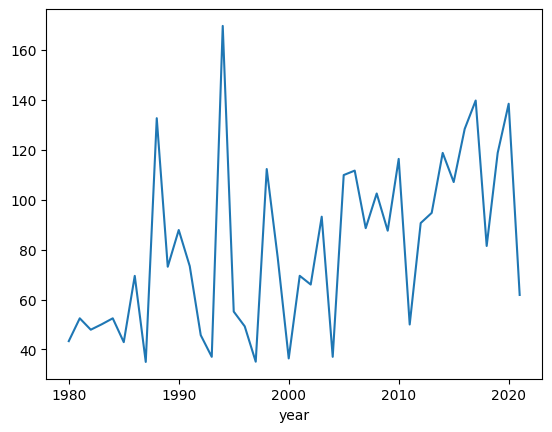

In [27]:
df_yearly.set_index("year")["value"].plot()

In [28]:
df_yearly.sort_values("date_1900")

,date,value,year,value_rank,value_rp,date_1900
18758,2005-06-04,109.920,2005,11.0,3.909091,1900-06-04
16918,2000-06-24,36.420,2000,40.0,1.075000,1900-06-24
19895,2008-06-25,102.533,2008,13.0,3.307692,1900-06-25
12085,1987-06-27,35.018,1987,42.0,1.023810,1900-06-27
15814,1997-07-05,35.100,1997,41.0,1.048780,1900-07-05
24749,2021-07-12,61.867,2021,27.0,1.592593,1900-07-12
21034,2011-07-17,50.020,2011,32.0,1.343750,1900-07-17
22895,2016-07-18,128.400,2016,5.0,8.600000,1900-07-18
22526,2015-07-21,107.120,2015,12.0,3.583333,1900-07-21
9507,1980-07-22,43.349,1980,36.0,1.194444,1900-07-22


<Axes: xlabel='year'>

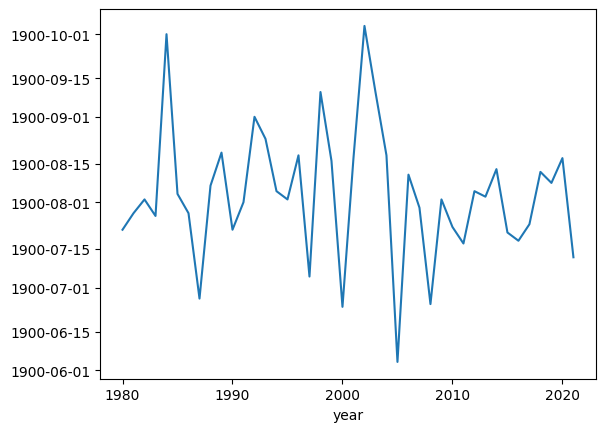

In [29]:
df_yearly.set_index("year")["date_1900"].plot()